In [1]:
import pandas as pd
from pathlib import Path

# Load dataset
project_root = Path.cwd().parent
data_path = project_root / "data" / "GlobalWeatherRepository.csv"

df = pd.read_csv(data_path)

df["last_updated"] = pd.to_datetime(df["last_updated"])

# Select Amman temperature
city_df = df[df["location_name"] == "Amman"].copy()

city_df = city_df.sort_values("last_updated")

daily_temperature_df = (
    city_df[["last_updated", "temperature_celsius"]]
    .set_index("last_updated")
    .resample("D")
    .mean()
    .ffill()
    .reset_index()
)

daily_temperature_df.head()


,last_updated,temperature_celsius
0,2024-05-16,24.0
1,2024-05-17,27.0
2,2024-05-18,30.0
3,2024-05-19,29.0
4,2024-05-20,30.0


In [2]:
daily_temperature_df["naive_prediction"] = (
    daily_temperature_df["temperature_celsius"].shift(1)
)
baseline_df = daily_temperature_df.dropna()

baseline_df.head()

,last_updated,temperature_celsius,naive_prediction
1,2024-05-17,27.0,24.0
2,2024-05-18,30.0,27.0
3,2024-05-19,29.0,30.0
4,2024-05-20,30.0,29.0
5,2024-05-21,29.0,30.0


In [3]:
# Split data into train and test (80/20) without shuffle

split_index = int(len(daily_temperature_df) * 0.8)

train_df = daily_temperature_df.iloc[:split_index].copy()
test_df = daily_temperature_df.iloc[split_index:].copy()

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print(train_df.tail())
print(test_df.head())

Train size: 628
Test size: 158
    last_updated  temperature_celsius  naive_prediction
623   2026-01-29                  9.0               9.3
624   2026-01-30                 11.3               9.0
625   2026-01-31                  9.2              11.3
626   2026-02-01                 13.3               9.2
627   2026-02-02                 15.2              13.3
    last_updated  temperature_celsius  naive_prediction
628   2026-02-03                  9.8              15.2
629   2026-02-04                  9.2               9.8
630   2026-02-05                 11.4               9.2
631   2026-02-06                 13.1              11.4
632   2026-02-07                 13.0              13.1


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare train and test series
train_series = train_df.set_index("last_updated")["temperature_celsius"]
test_series = test_df.set_index("last_updated")["temperature_celsius"]

# Build SARIMA model
model = SARIMAX(
    train_series,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

# Train model
sarima_model = model.fit()

print(sarima_model.summary())

c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hp\-Weather-Trend-Forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                     
Dep. Variable:               temperature_celsius   No. Observations:                  628
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1465.780
Date:                           Thu, 23 Jul 2026   AIC                           2941.561
Time:                                   13:11:36   BIC                           2963.709
Sample:                               05-16-2024   HQIC                          2950.170
                                    - 02-02-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6973      0.044     15.829      0.000       0.611       0.784
ma.L1         -0.9149      0.024    -37.539

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

forecast = sarima_model.forecast(steps=len(test_series))
mae = mean_absolute_error(test_series, forecast)

rmse = np.sqrt(
    mean_squared_error(test_series, forecast)
)
print("MAE:", mae)
print("RMSE:", rmse)


MAE: 11.841224838872359
RMSE: 14.480171108870588


In [6]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_series, forecast) * 100

print("MAPE:", mape, "%")

MAPE: 61.10639508256994 %


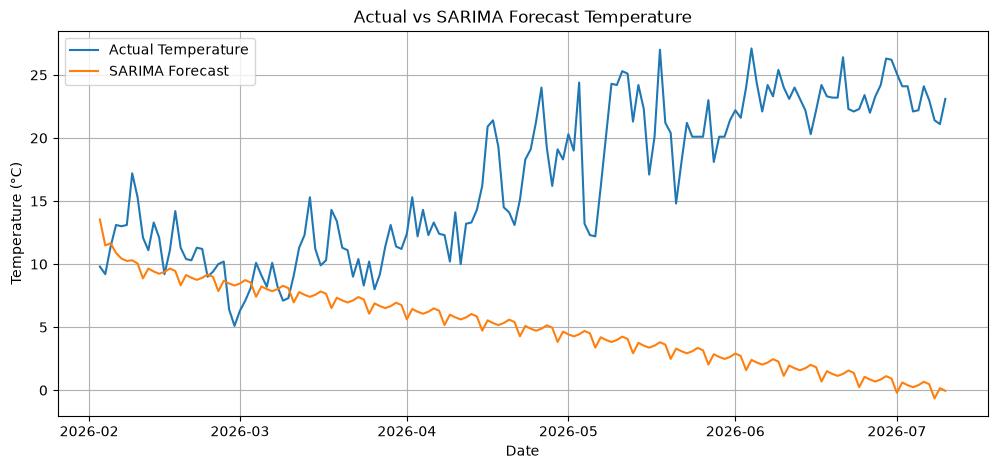

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test_series.index,
    test_series,
    label="Actual Temperature"
)

plt.plot(
    test_series.index,
    forecast,
    label="SARIMA Forecast"
)

plt.title("Actual vs SARIMA Forecast Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid()

plt.show()

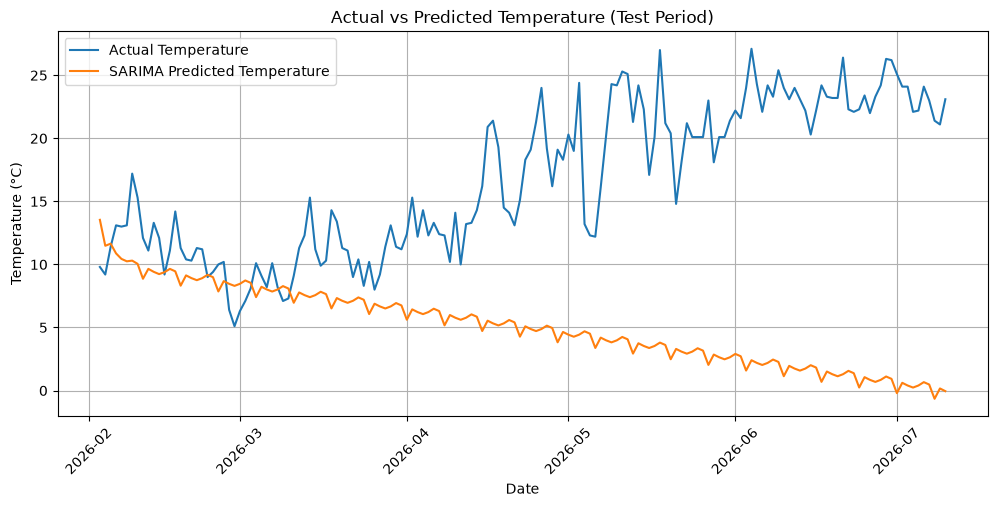

In [8]:
forecast = sarima_model.forecast(steps=len(test_series))
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    test_series.index,
    test_series,
    label="Actual Temperature"
)

plt.plot(
    test_series.index,
    forecast,
    label="SARIMA Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature (Test Period)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid()

plt.xticks(rotation=45)

plt.show()

In [10]:
# # Advanced Analysis - Anomaly Detection
# This section detects unusual temperature observations using the Z-score method.
# Extreme values may represent unusual weather events or possible measurement issues.

from scipy.stats import zscore

# Calculate Z-score for temperature
daily_temperature_df["temperature_zscore"] = zscore(
    daily_temperature_df["temperature_celsius"]
)

daily_temperature_df.head()

# Detect anomalies using Z-score threshold

anomalies = daily_temperature_df[
    abs(daily_temperature_df["temperature_zscore"]) > 3
]

print("Number of anomalies:", len(anomalies))

anomalies.head()

Number of anomalies: 0


,last_updated,temperature_celsius,naive_prediction,temperature_zscore


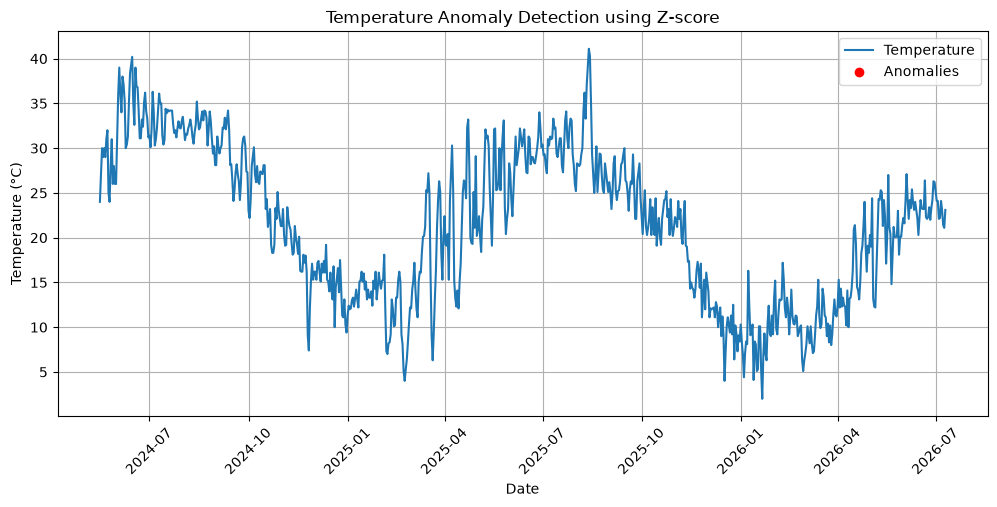

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    daily_temperature_df["last_updated"],
    daily_temperature_df["temperature_celsius"],
    label="Temperature"
)

plt.scatter(
    anomalies["last_updated"],
    anomalies["temperature_celsius"],
    color="red",
    label="Anomalies"
)

plt.title("Temperature Anomaly Detection using Z-score")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid()
plt.xticks(rotation=45)

plt.show()

In [14]:
# Model Comparison: SARIMA vs Random Forest
# A machine learning model using lag features is compared with the SARIMA forecasting model.

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Create lag features
ml_df = daily_temperature_df[["last_updated", "temperature_celsius"]].copy()

ml_df["lag_1"] = ml_df["temperature_celsius"].shift(1)
ml_df["lag_7"] = ml_df["temperature_celsius"].shift(7)

# Remove missing rows
ml_df = ml_df.dropna()

ml_df.head()






,last_updated,temperature_celsius,lag_1,lag_7
7,2024-05-23,32.0,31.0,24.0
8,2024-05-24,25.0,32.0,27.0
9,2024-05-25,24.0,25.0,30.0
10,2024-05-26,28.0,24.0,29.0
11,2024-05-27,31.0,28.0,30.0


In [15]:
split_index = int(len(ml_df) * 0.8)

train_ml = ml_df.iloc[:split_index]
test_ml = ml_df.iloc[split_index:]

X_train = train_ml[["lag_1", "lag_7"]]
y_train = train_ml["temperature_celsius"]

X_test = test_ml[["lag_1", "lag_7"]]
y_test = test_ml["temperature_celsius"]

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_prediction = rf_model.predict(X_test)

In [18]:
rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 2.220473336385837
Random Forest RMSE: 2.867335760199001


In [19]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse]
})

comparison

,Model,MAE,RMSE
0,SARIMA,11.841225,14.480171
1,Random Forest,2.220473,2.867336
